In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load Combined Dataset

In [24]:
# Load the combined_dataset
df = pd.read_csv('../data/processed/combined_student_data.csv')

# Display basic information about the dataset
print(f"Dataset loaded: {len(df)} student-course records")
print(f"Columns: {df.shape[1]}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded: 1044 student-course records
Columns: 35

First few rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,risk_category
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,math,High
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,math,High
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,math,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,math,Low
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,math,Medium


# 2. Deep analysis of study-related features vs G3:

### Study time vs G3 (boxplot, mean grades per study level)


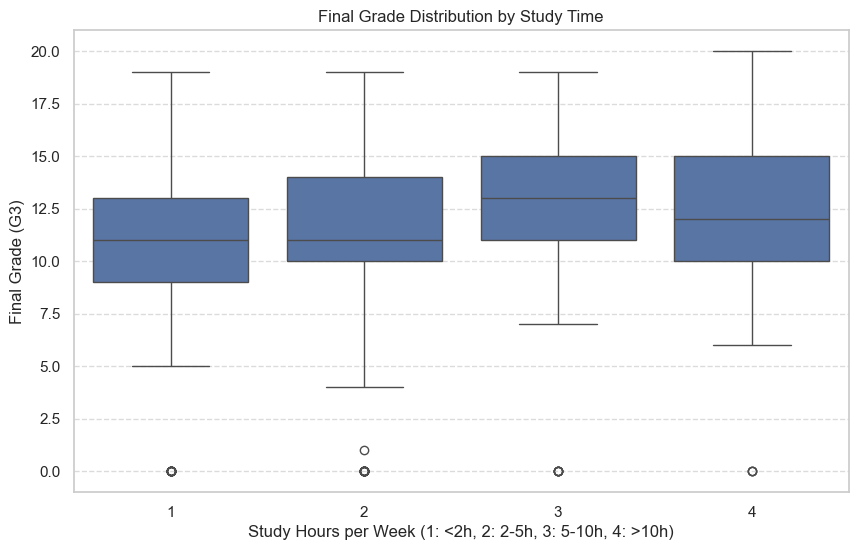


Mean Final Grades (G3) per Study Time Level:
   studytime         G3
0          1  10.580442
1          2  11.335984
2          3  12.493827
3          4  12.274194

Median Final Grades (G3) per Study Time Level:
   studytime    G3
0          1  11.0
1          2  11.0
2          3  13.0
3          4  12.0


In [34]:
# Analyze study habits and their impact on performance

# Correlation between study hours and final grade
plt.figure(figsize=(10, 6))



# Create boxplot to visualize the distribution of G3 for each studytime level
sns.boxplot(x='studytime', y='G3', data=df)
plt.title('Final Grade Distribution by Study Time')
plt.xlabel('Study Hours per Week (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate and display mean grades per study level
mean_grades_per_studytime = df.groupby('studytime')['G3'].mean().reset_index()
print("\nMean Final Grades (G3) per Study Time Level:")
print(mean_grades_per_studytime)

# Calculate and display median grades per study level
median_grades_per_studytime = df.groupby('studytime')['G3'].median().reset_index()
print("\nMedian Final Grades (G3) per Study Time Level:")
print(median_grades_per_studytime)




### Failures vs G3 (how past failures affect current performance)

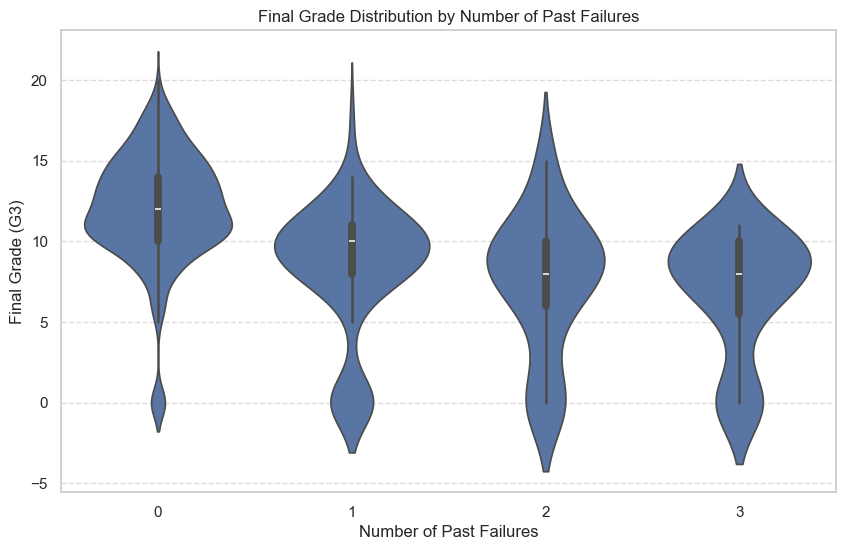


Mean Final Grades (G3) by Number of Past Failures:
<bound method Series.reset_index of failures
0    12.054588
1     8.425000
2     7.484848
3     6.800000
Name: G3, dtype: float64>

Median Final Grades (G3) by Number of Past Failures:
<bound method Series.reset_index of failures
0    12.0
1    10.0
2     8.0
3     8.0
Name: G3, dtype: float64>


In [33]:
#correlation between study hours and past failures
plt.figure(figsize=(10, 6))
# Create boxplot to visualize the distribution of G3 for each number of past failures
sns.violinplot(x='failures', y='G3', data=df)
plt.title('Final Grade Distribution by Number of Past Failures')
plt.xlabel('Number of Past Failures')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# take the mean of G3 for each level of failures
mean_grades_failures = df.groupby('failures')['G3'].mean().reset_index
print("\nMean Final Grades (G3) by Number of Past Failures:")
print(mean_grades_failures)

# take the median of G3 for each level of failures
median_grades_failures = df.groupby('failures')['G3'].median().reset_index
print("\nMedian Final Grades (G3) by Number of Past Failures:")
print(median_grades_failures)



### Schoolsup (School Support) vs G3 (does extra support help?)

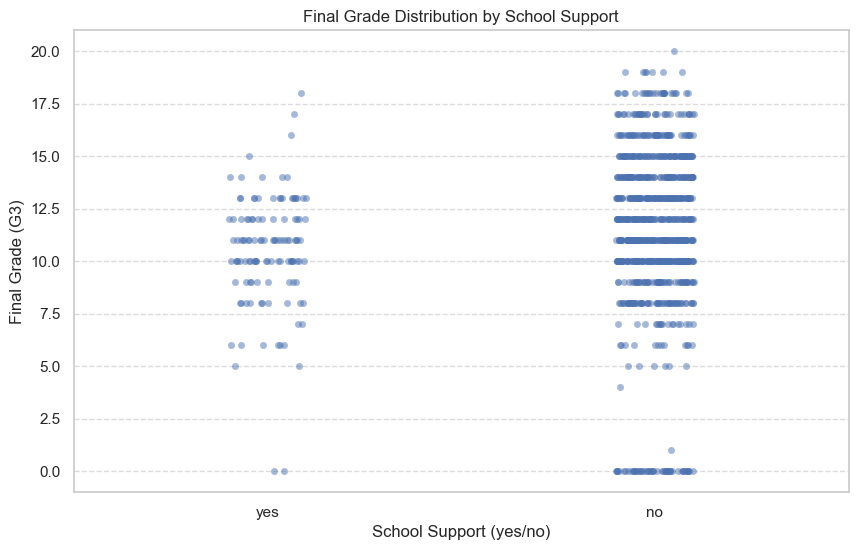


Mean Final Grades (G3) per School Support:
  schoolsup         G3
0        no  11.451892
1       yes  10.487395

Median Final Grades (G3) per School Support:
  schoolsup    G3
0        no  12.0
1       yes  11.0


In [32]:
# correlation between School support and final grade
plt.figure(figsize=(10, 6))
#creata a stripplot to visualize the distribution of G3 for each level of school support
sns.stripplot(x='schoolsup', y='G3', data=df, jitter=True, alpha=0.5)
plt.title('Final Grade Distribution by School Support')
plt.xlabel('School Support (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#take the mean of G3 for each level of school support
mean_grades_per_schoolsup = df.groupby('schoolsup')['G3'].mean().reset_index()
print("\nMean Final Grades (G3) per School Support:")
print(mean_grades_per_schoolsup)

# take the median of G3 for each level of school support
median_grades_per_schoolsup = df.groupby('schoolsup')['G3'].median().reset_index()
print("\nMedian Final Grades (G3) per School Support:")
print(median_grades_per_schoolsup)




#### Does extra support help?

No, as per the graph, student who did not receive support from the school score generally the same or higher than those who receive the support.

### Paid classes vs G3 (do paid classes improve grades?)

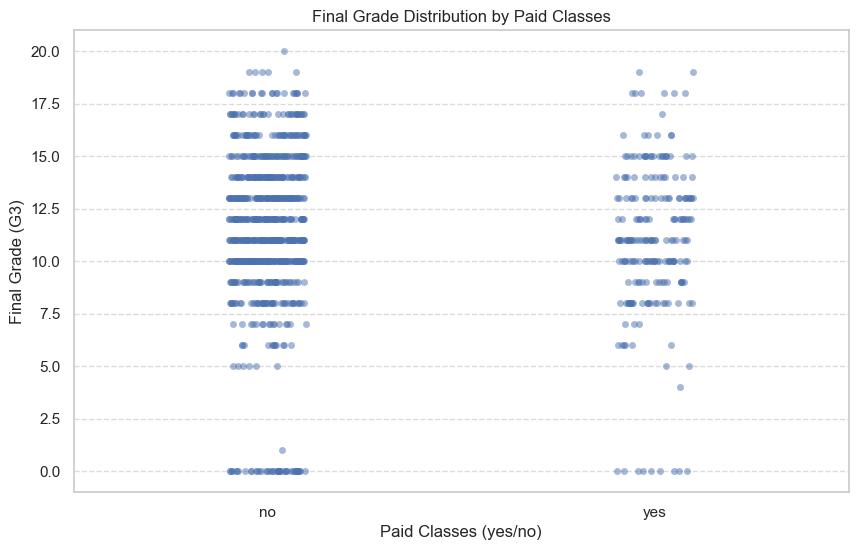


Mean Final Grades (G3) by Paid Classes:
  paid         G3
0   no  11.440534
1  yes  10.972727

Median Final Grades (G3) by Paid Classes:
  paid    G3
0   no  12.0
1  yes  11.0


In [31]:
# correlation between paid classes and final grade
plt.figure(figsize=(10, 6))
# Create a stripplot to visualize the distribution of G3 for each level of paid classes
sns.stripplot(x='paid', y='G3', data=df, jitter=True, alpha=0.5)
plt.title('Final Grade Distribution by Paid Classes')
plt.xlabel('Paid Classes (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# take the mean of G3 for each level of paid classes
mean_grades_paid = df.groupby('paid')['G3'].mean().reset_index()
print("\nMean Final Grades (G3) by Paid Classes:")
print(mean_grades_paid)

# take median of G3 for each level of paid classes
median_grades_paid = df.groupby('paid')['G3'].median().reset_index()
print("\nMedian Final Grades (G3) by Paid Classes:")
print(median_grades_paid)



#### Do paid classes improve grades?

As per the graph, student who take paid classes have about an average or slightly above average score while those that do not take paid classes have similar or better scores.

### Activities vs G3 (extracurriculars impact)


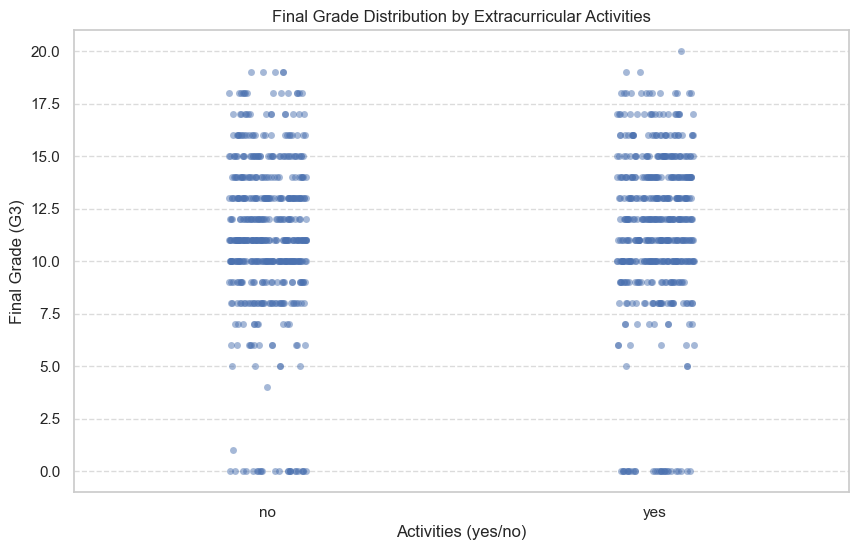


Mean Final Grades (G3) by Extracurricular Activities:
  activities         G3
0         no  11.212121
1        yes  11.474806

Median Final Grades (G3) by Extracurricular Activities:
  activities    G3
0         no  11.0
1        yes  12.0


In [30]:
# correlation between extracurricular activities and final grade
plt.figure(figsize=(10, 6))
sns.stripplot(x='activities', y='G3', data=df, jitter=True, alpha=0.5)
plt.title('Final Grade Distribution by Extracurricular Activities')
plt.xlabel('Activities (yes/no)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# take the mean of G3 for each level of activities
mean_grades_activities = df.groupby('activities')['G3'].mean().reset_index()
print("\nMean Final Grades (G3) by Extracurricular Activities:")
print(mean_grades_activities)

# take the median of G3 for each level of activities
median_grades_activities = df.groupby('activities')['G3'].median().reset_index()
print("\nMedian Final Grades (G3) by Extracurricular Activities:")
print(median_grades_activities)

#### Do the Extracurricular activities effect final grade?

No, there is generally an even split between the grades of the students. This indicates that performance is fairly balanced across the cohort, with no single grade bracket dominating.